### 06 - Regression Lineaire
#### HumanForYou - Attrition ML

Objectif : reproduire les approches de regression lineaire du workshop (equation normale, OLS Statsmodels, LinearRegression sklearn).

- **Entrees** : `data/processed/housing_train_prepared.csv`, `data/processed/housing_test_prepared.csv`
- **Sorties** : `data/processed/housing_linear_metrics.csv`, `data/processed/housing_linear_test_predictions.csv`


#### 1. Imports et chemins

Cette cellule importe les dependances necessaires et prepare les chemins d'entree/sortie.


In [1]:
# Imports pour les modeles lineaires, metriques et visualisations.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


#### 2. Chargement des jeux preprocesses

Cette etape charge les jeux train/test prepares dans le notebook precedent.


In [2]:
# Chargement des datasets preprocesses et separation features/cible.
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
train_path = os.path.join(PROCESSED_DIR, 'housing_train_prepared.csv')
test_path = os.path.join(PROCESSED_DIR, 'housing_test_prepared.csv')

assert os.path.exists(train_path), f'Fichier introuvable: {train_path}'
assert os.path.exists(test_path), f'Fichier introuvable: {test_path}'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=['median_house_value']).copy()
y_train = train_df['median_house_value'].copy()
X_test = test_df.drop(columns=['median_house_value']).copy()
y_test = test_df['median_house_value'].copy()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (16512, 16), X_test: (4128, 16)


#### 3. Equation normale (sous-ensemble de variables)

Cette section applique la solution analytique OLS sur deux variables explicatives, comme dans le workshop.


In [3]:
# Estimation analytique des coefficients sur deux features (total_rooms et median_income).
def find_feature(columns, base_name):
    candidates = [c for c in columns if c == base_name or c.endswith(f'__{base_name}')]
    assert len(candidates) > 0, f'Feature non trouvee: {base_name}'
    return candidates[0]

total_rooms_col = find_feature(X_train.columns, 'total_rooms')
median_income_col = find_feature(X_train.columns, 'median_income')

X_ne = X_train[[total_rooms_col, median_income_col]].copy()
X_ne['bias'] = 1.0

theta_ne = np.linalg.pinv(X_ne.to_numpy()) @ y_train.to_numpy()
y_pred_ne = X_ne.to_numpy() @ theta_ne

normal_eq_mse_train = mean_squared_error(y_train, y_pred_ne)
print('Features utilisees:', [total_rooms_col, median_income_col])
print('Theta (equation normale):', theta_ne)
print('Train MSE (equation normale):', round(normal_eq_mse_train, 2))


Features utilisees: ['num__total_rooms', 'num__median_income']
Theta (equation normale): [  -287.07245313  79559.25623317 207005.32237161]
Train MSE (equation normale): 7065363569.65


#### 4. OLS avec Statsmodels

Ici, on entraine un modele OLS sur toutes les features preprocesses pour analyser coefficients et p-values.


In [4]:
# Ajustement OLS complet avec constante explicite.
X_sm = sm.add_constant(X_train, has_constant='add')
ols_model = sm.OLS(y_train, X_sm).fit()

coef_table = pd.DataFrame({
    'feature': ols_model.params.index,
    'coefficient': ols_model.params.values,
    'p_value': ols_model.pvalues.values,
}).sort_values('p_value', ascending=True)

print(ols_model.summary().as_text()[:2500])
coef_table.head(10)


                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     2069.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:44:18   Log-Likelihood:            -2.0720e+05
No. Observations:               16512   AIC:                         4.144e+05
Df Residuals:                   16496   BIC:                         4.146e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

,feature,coefficient,p_value
8,num__median_income,78265.159947,0.000000e+00
6,num__population,-46114.163689,1.884257e-242
1,num__longitude,-56046.338967,2.175277e-131
0,const,196282.518329,7.533631e-129
2,num__latitude,-56657.828766,2.445897e-121
3,num__housing_median_age,13931.569388,7.136256e-113
11,num__bedrooms_per_room,16859.186156,1.515576e-80
7,num__households,42894.507070,9.520669e-44
9,num__rooms_per_household,7278.006851,2.242551e-27
14,cat__ocean_proximity_ISLAND,145001.570312,3.113450e-04


#### 5. Regression lineaire sklearn + evaluation test

Cette etape entraine `LinearRegression` puis evalue ses performances sur train et test.


In [5]:
# Entrainement sklearn puis calcul des metriques train/test.
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

metrics_df = pd.DataFrame([
    {
        'model': 'NormalEquation_2features',
        'rmse_train': float(np.sqrt(normal_eq_mse_train)),
        'r2_train': float(r2_score(y_train, y_pred_ne)),
        'rmse_test': np.nan,
        'r2_test': np.nan,
    },
    {
        'model': 'LinearRegression_sklearn',
        'rmse_train': float(np.sqrt(mean_squared_error(y_train, y_pred_train))),
        'r2_train': float(r2_score(y_train, y_pred_train)),
        'rmse_test': float(np.sqrt(mean_squared_error(y_test, y_pred_test))),
        'r2_test': float(r2_score(y_test, y_pred_test)),
    },
])

metrics_df


,model,rmse_train,r2_train,rmse_test,r2_test
0,NormalEquation_2features,84055.717055,0.472182,NaN,NaN
1,LinearRegression_sklearn,68160.924355,0.652927,66803.138908,0.657592


#### 6. Visualisations et exports

Cette section sauvegarde les metriques, les predictions test et deux figures utiles d'interpretation.


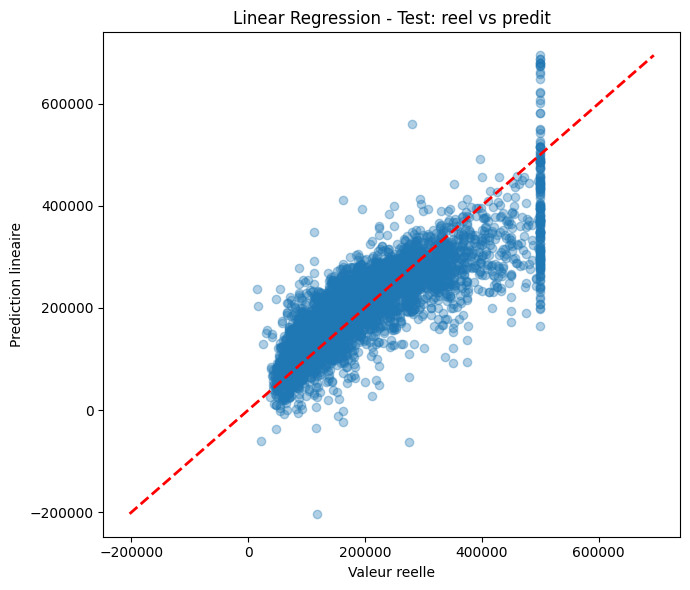

<Figure size 800x600 with 0 Axes>

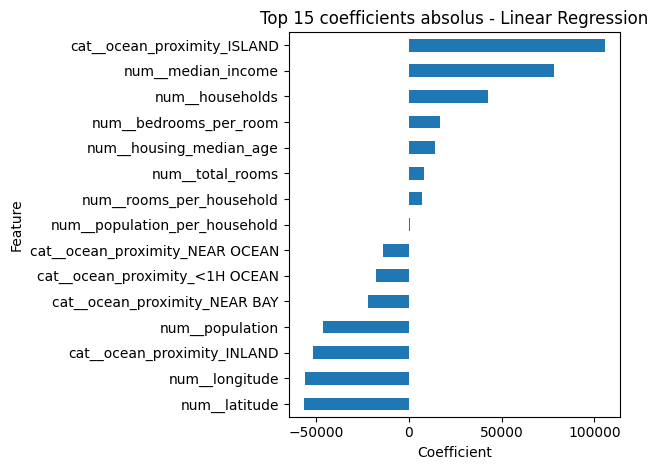

Saved: ..\data\processed\housing_linear_metrics.csv
Saved: ..\data\processed\housing_linear_test_predictions.csv
Saved: ..\data\processed\housing_linear_coefficients.csv


In [6]:
# Export des artefacts lineaires et creation des figures principales.
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

predictions_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_linear': y_pred_test,
    'residual': y_test - y_pred_test,
})

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lin_reg.coef_,
}).sort_values('coefficient', key=np.abs, ascending=False)

metrics_path = os.path.join(PROCESSED_DIR, 'housing_linear_metrics.csv')
preds_path = os.path.join(PROCESSED_DIR, 'housing_linear_test_predictions.csv')
coef_path = os.path.join(PROCESSED_DIR, 'housing_linear_coefficients.csv')

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(preds_path, index=False)
coef_df.to_csv(coef_path, index=False)

plt.figure(figsize=(7, 6))
plt.scatter(predictions_df['y_true'], predictions_df['y_pred_linear'], alpha=0.35)
min_val = min(predictions_df['y_true'].min(), predictions_df['y_pred_linear'].min())
max_val = max(predictions_df['y_true'].max(), predictions_df['y_pred_linear'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Valeur reelle')
plt.ylabel('Prediction lineaire')
plt.title('Linear Regression - Test: reel vs predit')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'regression_linear_actual_vs_pred.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
coef_df.head(15).sort_values('coefficient').plot(kind='barh', x='feature', y='coefficient', legend=False)
plt.title('Top 15 coefficients absolus - Linear Regression')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'regression_linear_top_coefficients.png'), dpi=300)
plt.show()

print(f'Saved: {metrics_path}')
print(f'Saved: {preds_path}')
print(f'Saved: {coef_path}')


#### 7. Validation

Cette cellule confirme que les fichiers de sortie sont bien presents et exploitables.


In [7]:
# Validation finale des sorties creees par ce notebook.
assert os.path.exists(metrics_path), 'Metrics file manquant'
assert os.path.exists(preds_path), 'Predictions file manquant'
assert os.path.exists(coef_path), 'Coefficients file manquant'
assert {'model', 'rmse_train', 'r2_train'}.issubset(metrics_df.columns), 'Colonnes metrics incompletes'
assert len(predictions_df) == len(y_test), 'Taille predictions incoherente'

print('Validation OK pour 06_Regression_Lineaire.ipynb')


Validation OK pour 06_Regression_Lineaire.ipynb
